In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("insurance.csv")

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# encoding

In [7]:
encode = pd.get_dummies(df,columns = ["sex","smoker","region"],drop_first = True,dtype = int)

# Calculating correlation with charges

In [24]:
corr = encode.corr()
corr['charges'].sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64

# Correlation Analysis of Features Affecting Insurance Charges

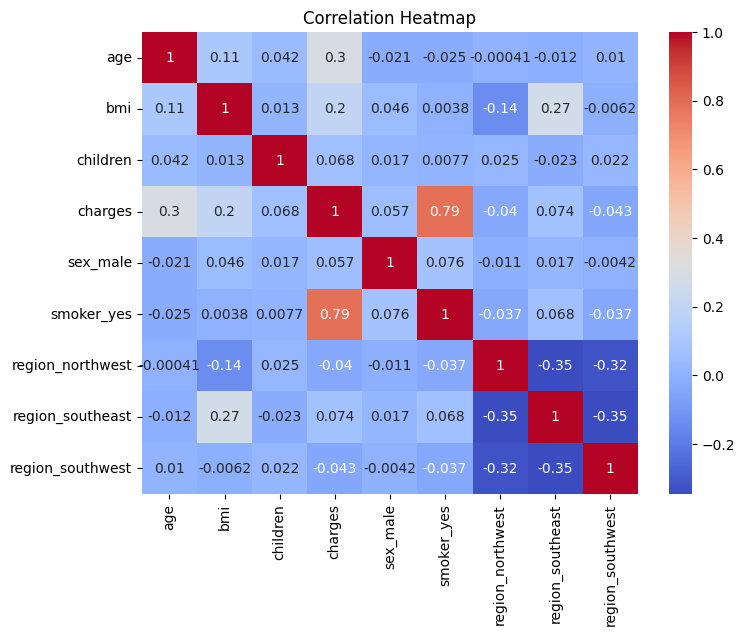

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ...........................................................................................................................................................

# Relationship Between Customer Attributes and Insurance Charges

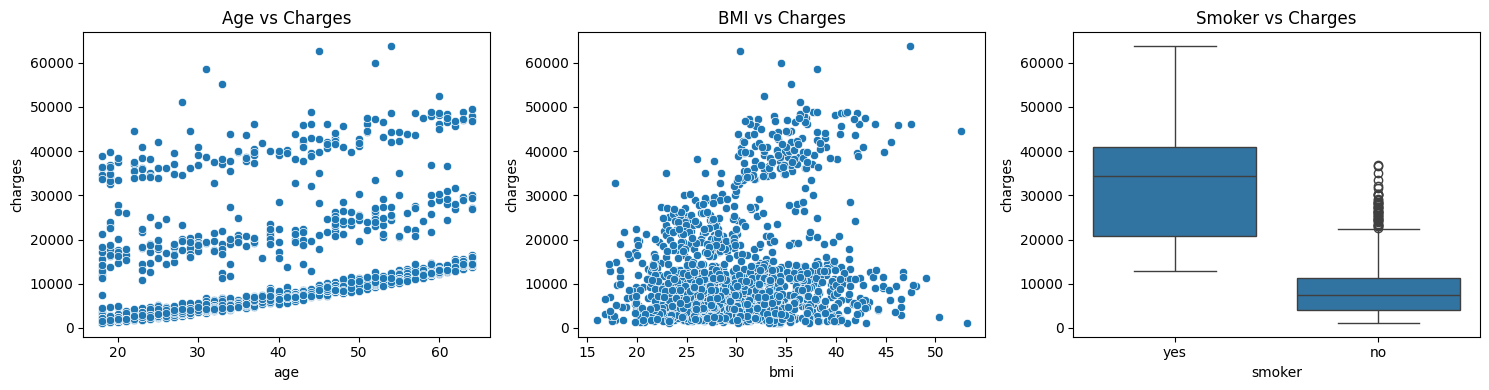

In [28]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.scatterplot(x=df['age'], y=df['charges'])
plt.title("Age vs Charges")

plt.subplot(1,3,2)
sns.scatterplot(x=df['bmi'], y=df['charges'])
plt.title("BMI vs Charges")

plt.subplot(1,3,3)
sns.boxplot(x=df['smoker'], y=df['charges'])
plt.title("Smoker vs Charges")

plt.tight_layout()
plt.show()

In [17]:
encode.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [8]:
x = encode.drop(columns = ["charges"])
y = encode["charges"]

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# dividing data into train and test 

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)


# applying Standardization

In [11]:
scaled = StandardScaler()
x_train_scaled = scaled.fit_transform(x_train)
x_test_scaled = scaled.transform(x_test)

In [18]:
x_train_scaled

array([[ 0.47222651, -1.75652513,  0.73433626, ...,  1.78316783,
        -0.59966106, -0.5723141 ],
       [ 0.54331294, -1.03308239, -0.91119211, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [ 0.8987451 , -0.94368672, -0.91119211, ..., -0.56079971,
         1.66760869, -0.5723141 ],
       ...,
       [ 1.3252637 , -0.89153925, -0.91119211, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [-0.16755139,  2.82086429,  0.73433626, ..., -0.56079971,
        -0.59966106,  1.74729228],
       [ 1.1120044 , -0.10932713, -0.91119211, ..., -0.56079971,
        -0.59966106,  1.74729228]], shape=(1070, 8))

# applying linear regression model

In [12]:
model = LinearRegression()
model.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# predicting the y_pred

In [13]:
y_pred = model.predict(x_test_scaled)

# evaluating with actual value(y_test) vs predicted value(y_pred)

In [14]:

from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

print("R2:", (r2_score(y_test, y_pred))*100)
print("MAE:", (mean_absolute_error(y_test, y_pred)))
print("RMSE:", (np.sqrt(mean_squared_error(y_test, y_pred))))

R2: 78.35929767120722
MAE: 4181.194473753654
RMSE: 5796.284659276275


# applying the another regression model RandomForestRegressor
<h3>In same training and testing dataset <h3>

In [15]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
model.fit(x_train, y_train)


,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#  predicting the Y_pred

In [ ]:
Y_pred = model.predict(x_test)

# evaluating with actual value(y_test) vs predicted value(y_pred)

In [42]:
print("R2:", r2_score(y_test, Y_pred)*100)
print("MAE:", mean_absolute_error(y_test, Y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, Y_pred)))

R2: 86.36607070893616
MAE: 2559.543954241044
RMSE: 4600.706714936517


<h1>Conclusion</h1>

In this project, we built machine learning models to predict medical insurance charges using features such as age, BMI, smoking status, number of children, gender, and region. After preprocessing the dataset and encoding categorical variables, two models—Linear Regression and Random Forest Regressor—were trained and evaluated. Linear Regression achieved an R² score of about 0.78, while Random Forest performed better with an R² score of about 0.86 and lower prediction errors. This shows that Random Forest was able to capture the patterns in the data more effectively. Overall, the results suggest that ensemble models like Random Forest are more suitable for this dataset compared to simple linear models.
